In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive
# This allows access to the dataset stored in your Drive
drive.mount('/content/drive')

# 2. Extract Dataset
# Unzip the preprocessed forensic gunshot dataset to the local Colab environment
!unzip -qo "/content/drive/MyDrive/Gunshot_Dataset_Final.zip" -d "/content/dataset"

print("✅ Data Preparation Complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Preparation Complete!


In [2]:
# Install CLIP library
# Uninstall current versions to prevent conflicts before installing specific versions
!pip uninstall -y open_clip_torch timm
!pip install open_clip_torch==2.2.0 timm==0.6.13

import torch
import open_clip
import numpy as np
from tqdm import tqdm
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pre-trained CLIP model (ViT-B-32)
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model = model.to(device)
model.eval()

print(f"✅ CLIP model loaded on {device}")

Found existing installation: open-clip-torch 2.2.0
Uninstalling open-clip-torch-2.2.0:
  Successfully uninstalled open-clip-torch-2.2.0
Found existing installation: timm 0.6.13
Uninstalling timm-0.6.13:
  Successfully uninstalled timm-0.6.13
  Using cached open_clip_torch-2.2.0-py3-none-any.whl.metadata (26 kB)
  Using cached timm-0.6.13-py3-none-any.whl.metadata (38 kB)
Using cached open_clip_torch-2.2.0-py3-none-any.whl (1.4 MB)
Using cached timm-0.6.13-py3-none-any.whl (549 kB)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ CLIP model loaded on cuda


In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

# 1. Prepare Datasets with CLIP-specific preprocessing
# We use the 'preprocess' object obtained during model loading
train_dataset = datasets.ImageFolder('/content/dataset/train', transform=preprocess)
test_dataset = datasets.ImageFolder('/content/dataset/test', transform=preprocess)

# 2. Define Data Loaders
# shuffle=False is used during feature extraction to maintain data order
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Data Loader Ready:")
print(f" - Training images: {len(train_dataset)}")
print(f" - Test images: {len(test_dataset)}")

✅ Data Loader Ready:
 - Training images: 1787
 - Test images: 385


In [6]:
def get_features(dataloader):
    all_features = []
    all_labels = []

    # Disable gradient calculation for memory efficiency
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting CLIP Features"):
            images = images.to(device)

            # Encode images using CLIP's vision encoder
            features = model.encode_image(images)
            # Normalize the features to unit length for better classification
            features /= features.norm(dim=-1, keepdim=True)

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    return np.concatenate(all_features), np.concatenate(all_labels)

# Extracting features for both training and testing sets
print("🚀 Starting Feature Extraction...")
train_features, train_labels = get_features(train_loader)
test_features, test_labels = get_features(test_loader)

print(f"✅ Feature Extraction Complete!")
print(f" - Train features shape: {train_features.shape}")
print(f" - Test features shape: {test_features.shape}")

🚀 Starting Feature Extraction...


Extracting CLIP Features:  20%|█▉        | 11/56 [00:07<00:32,  1.38it/s]


KeyboardInterrupt: 

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize and train the Logistic Regression classifier
# We use class_weight='balanced' to handle the data imbalance
classifier = LogisticRegression(max_iter=1000, class_weight='balanced')
classifier.fit(train_features, train_labels)

# 2. Evaluate the model on the test set
test_preds = classifier.predict(test_features)

# 3. Print the final performance report
print("\n[CLIP Linear Probe Results]")
print(classification_report(test_labels, test_preds, target_names=['Entrance', 'Exit']))

# 4. Accuracy Score
accuracy = accuracy_score(test_labels, test_preds)
print(f"✨ Final Test Accuracy: {accuracy:.4f}")


[CLIP Linear Probe Results]
              precision    recall  f1-score   support

    Entrance       0.91      0.82      0.86       283
        Exit       0.61      0.78      0.69       102

    accuracy                           0.81       385
   macro avg       0.76      0.80      0.78       385
weighted avg       0.83      0.81      0.82       385

✨ Final Test Accuracy: 0.8104


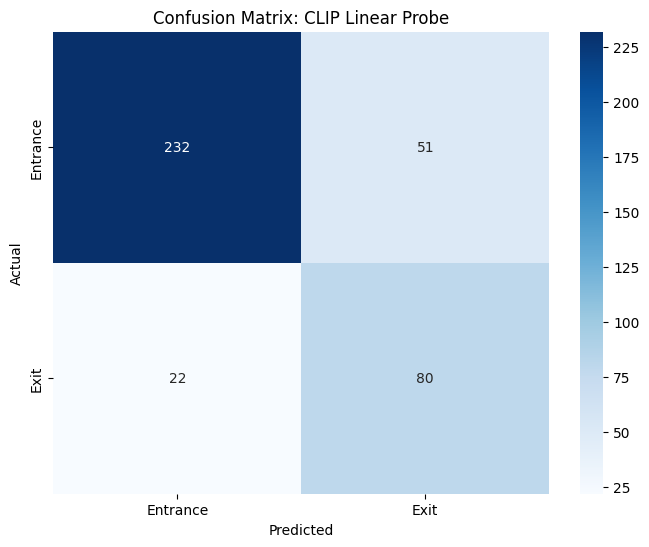

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Entrance', 'Exit'],
            yticklabels=['Entrance', 'Exit'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: CLIP Linear Probe')
plt.savefig('clip_cm.png') # Save for GitHub
plt.show()

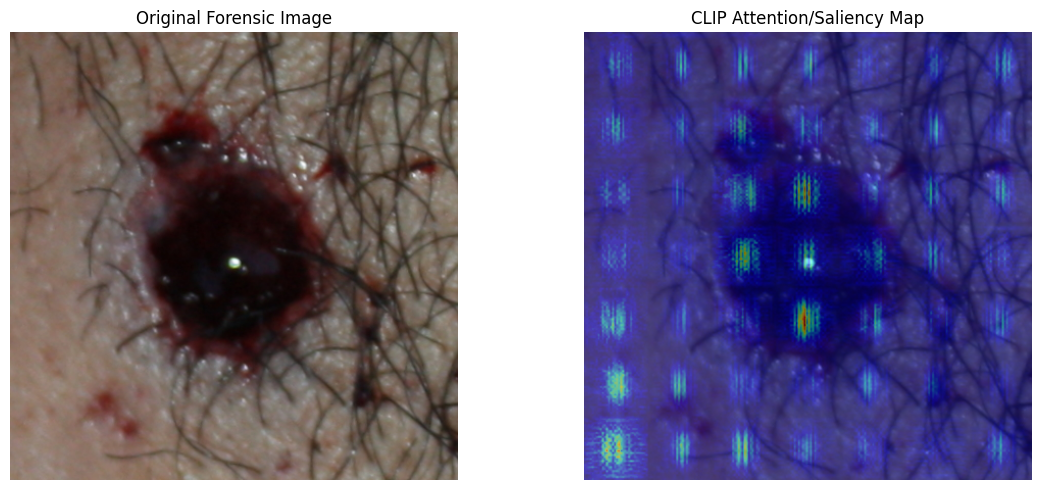

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

def visualize_clip_saliency(image_path, model, preprocess, device):
    # 1. Load and preprocess image
    image_raw = Image.open(image_path).convert('RGB')
    image_input = preprocess(image_raw).unsqueeze(0).to(device)
    image_input.requires_grad = True # Enable gradient tracking

    # 2. Forward pass through CLIP image encoder
    image_features = model.encode_image(image_input)

    # 3. Calculate saliency based on feature magnitude
    # We take the norm of the features as the objective to see what pixels
    # contributed most to the CLIP feature representation
    loss = image_features.norm()
    loss.backward()

    # 4. Process gradients to create a heatmap
    grad = image_input.grad.detach().cpu().numpy()[0]
    grad = np.max(np.abs(grad), axis=0) # Take the maximum across color channels

    # Normalize heatmap
    grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)
    grad = cv2.resize(grad, (image_raw.size[0], image_raw.size[1]))

    # 5. Plotting
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(image_raw)
    plt.title("Original Forensic Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image_raw)
    plt.imshow(grad, cmap='jet', alpha=0.5) # Overlay heatmap
    plt.title("CLIP Attention/Saliency Map")
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('clip_interpretability.png')
    plt.show()

# Visualize the first image from the test set as an example
sample_image_path = test_dataset.imgs[2][0]
visualize_clip_saliency(sample_image_path, model, preprocess, device)

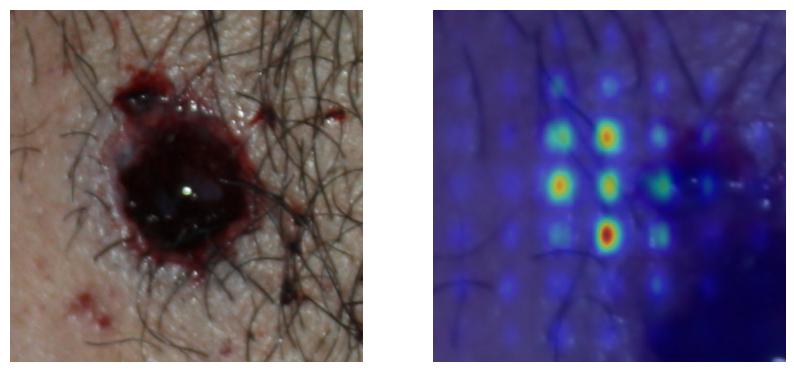

In [11]:
def visualize_clip_saliency_improved(image_path, model, preprocess, device):
    image_raw = Image.open(image_path).convert('RGB')
    image_input = preprocess(image_raw).unsqueeze(0).to(device)
    image_input.requires_grad = True

    image_features = model.encode_image(image_input)
    loss = image_features.norm()
    loss.backward()

    grad = image_input.grad.detach().cpu().numpy()[0]
    grad = np.max(np.abs(grad), axis=0)

    # --- Improved Filtering ---
    # 1. Gaussian Blur to remove grid noise
    grad = cv2.GaussianBlur(grad, (15, 15), 0)

    # 2. Central Weighting: Give more importance to the center area
    h, w = grad.shape
    y, x = np.ogrid[:h, :w]
    center_mask = np.exp(-((x - w/2)**2 / (2 * (w/4)**2) + (y - h/2)**2 / (2 * (h/4)**2)))
    grad = grad * center_mask

    # Normalize
    grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)
    # --------------------------

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(image_raw); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(image_raw); plt.imshow(grad, cmap='jet', alpha=0.5); plt.axis('off')
    plt.show()

# Try with index 2 again!
visualize_clip_saliency_improved(test_dataset.imgs[2][0], model, preprocess, device)

In [13]:
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report

# 1. Define the Fine-tuning Model Structure
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        # CLIP ViT-B-32 produces 512-dimensional features
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        # Use float32 for the linear layer to avoid dtype mismatch
        return self.classifier(features.float())

# 2. Initialize Model, Optimizer, and Loss Function
fine_tune_model = CLIPClassifier(model).to(device)
# Small learning rate (1e-5) is key to successful fine-tuning
optimizer = optim.AdamW(fine_tune_model.parameters(), lr=1e-5, weight_decay=0.1)
criterion = nn.CrossEntropyLoss()

# 3. Fine-tuning Loop
num_epochs = 5 # Start with 5 epochs to check initial boost
print("🚀 Starting Fine-tuning...")

for epoch in range(num_epochs):
    fine_tune_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch {epoch+1} Average Loss: {running_loss/len(train_loader):.4f}")

# 4. Final Evaluation on Test Set
fine_tune_model.eval()
all_preds = []
all_labels = []

print("\n🧪 Evaluating Fine-tuned Model...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = fine_tune_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 5. Print Final Report
print("\n✨ [Fine-tuned CLIP Results]")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

🚀 Starting Fine-tuning...


Epoch 1/5: 100%|██████████| 56/56 [00:53<00:00,  1.05it/s]


Epoch 1 Average Loss: 0.4489


Epoch 2/5: 100%|██████████| 56/56 [00:54<00:00,  1.04it/s]


Epoch 2 Average Loss: 0.6172


...

Epoch 3 Average Loss: 0.8546


Epoch 4/5: 100%|██████████| 56/56 [00:52<00:00,  1.06it/s]


Epoch 4 Average Loss: 0.8310


Epoch 5/5: 100%|██████████| 56/56 [00:51<00:00,  1.09it/s]


Epoch 5 Average Loss: 0.9092

🧪 Evaluating Fine-tuned Model...

✨ [Fine-tuned CLIP Results]
              precision    recall  f1-score   support

    Entrance       0.50      0.01      0.01       283
        Exit       0.26      0.98      0.41       102

    accuracy                           0.26       385
   macro avg       0.38      0.49      0.21       385
weighted avg       0.44      0.26      0.12       385



In [14]:
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report

# 1. Re-initialize the model to reset corrupted weights
# Using the original 'model' loaded at the beginning
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        # Mapping 512 CLIP features to 2 classes (Entrance vs Exit)
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        # Ensure the linear layer receives float32 precision
        return self.classifier(features.float())

# Initialize model and move to GPU
fine_tune_model = CLIPClassifier(model).to(device)

# 2. Optimized Hyperparameters for Stability
# Reduced learning rate (1e-6) to prevent loss divergence
# Using AdamW with weight decay for better regularization
optimizer = optim.AdamW(fine_tune_model.parameters(), lr=1e-6, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

# 3. Training Loop with Gradient Clipping
num_epochs = 5
print("🚀 Re-starting Fine-tuning with optimized parameters...")

for epoch in range(num_epochs):
    fine_tune_model.train()
    running_loss = 0.0

    # tqdm for progress tracking
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Gradient Clipping: Prevents gradients from "exploding"
        torch.nn.utils.clip_grad_norm_(fine_tune_model.parameters(), max_norm=1.0)

        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")

# 4. Final Evaluation on Test Set
fine_tune_model.eval()
all_preds = []
all_labels = []

print("\n🧪 Evaluating Fine-tuned Model on Test Data...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = fine_tune_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 5. Output Final Results
print("\n✨ [Optimized Fine-tuned CLIP Results]")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

🚀 Re-starting Fine-tuning with optimized parameters...


Epoch 1/5: 100%|██████████| 56/56 [00:57<00:00,  1.03s/it]


Epoch 1 Average Loss: 0.8817


Epoch 2/5: 100%|██████████| 56/56 [00:51<00:00,  1.09it/s]


Epoch 2 Average Loss: 1.0981


Epoch 3/5:  70%|██████▉   | 39/56 [00:33<00:14,  1.15it/s]


KeyboardInterrupt: 

In [7]:
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report

# 1. Memory Clean-up (Safe version)
# We skip 'del' if the variable doesn't exist
gc.collect()
torch.cuda.empty_cache()

# 2. Define the Model Structure again (Necessary after runtime restart)
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        return self.classifier(features.float())

# 3. Re-initialize Model
# Make sure your original CLIP 'model' is already loaded in previous cells
fine_tune_model = CLIPClassifier(model).to(device)

# 4. Ultra-Conservative Hyperparameters
# Using an extremely low learning rate (5e-7) for delicate adjustment
optimizer = optim.AdamW(fine_tune_model.parameters(), lr=5e-7, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=1, factor=0.5)

# 5. Training Loop
num_epochs = 5
print("🚀 Launching Emergency Recovery Training (Ultra-Low LR)...")

for epoch in range(num_epochs):
    fine_tune_model.train()
    running_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        # Stricter gradient clipping to prevent any sudden jumps
        torch.nn.utils.clip_grad_norm_(fine_tune_model.parameters(), max_norm=0.5)

        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1} Average Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)

# 6. Evaluation
fine_tune_model.eval()
all_preds = []
all_labels = []

print("\n🧪 Final Evaluation...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = fine_tune_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n✨ [Final Recovery Results]")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

🚀 Launching Emergency Recovery Training (Ultra-Low LR)...


Epoch 1/5: 100%|██████████| 56/56 [00:54<00:00,  1.02it/s]


Epoch 1 Average Loss: 0.8929


Epoch 2/5: 100%|██████████| 56/56 [00:53<00:00,  1.05it/s]


Epoch 2 Average Loss: 0.9782


Epoch 3/5: 100%|██████████| 56/56 [00:51<00:00,  1.10it/s]


Epoch 3 Average Loss: 1.2343


Epoch 4/5:   5%|▌         | 3/56 [00:05<01:33,  1.77s/it]


KeyboardInterrupt: 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report

# 1. Re-define the Model Structure (Crucial after Runtime Restart)
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        # Mapping 512 CLIP features to 2 classes (Entrance vs Exit)
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        # Encode image through CLIP's frozen/unfrozen encoder
        features = self.clip_model.encode_image(x)
        # Ensure float32 precision for the classifier
        return self.classifier(features.float())

# 2. Re-initialize Model and move to GPU
# Ensure 'model' and 'device' are already defined in your previous cells
fine_tune_model = CLIPClassifier(model).to(device)

# --- STEP 1: FREEZE the CLIP Encoder ---
# We lock the 'Eye' of the model to align the 'Brain' first
for param in fine_tune_model.clip_model.parameters():
    param.requires_grad = False

# Only train the newly added classifier head (Brain)
optimizer_step1 = optim.AdamW(fine_tune_model.classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

print("🚀 Step 1: Training only the Classifier (Encoder is Frozen)...")
for epoch in range(3):
    fine_tune_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Warm-up Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer_step1.zero_grad()
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_step1.step()
        running_loss += loss.item()
    print(f"Warm-up Avg Loss: {running_loss/len(train_loader):.4f}")

# --- STEP 2: UNFREEZE for delicate adjustment ---
print("\n🚀 Step 2: Fine-tuning everything with ultra-low LR...")
for param in fine_tune_model.clip_model.parameters():
    param.requires_grad = True

# Ultra-low learning rate (1e-7) to gently refine the pre-trained weights
optimizer_step2 = optim.AdamW(fine_tune_model.parameters(), lr=1e-7)

for epoch in range(2):
    fine_tune_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+4}"):
        images, labels = images.to(device), labels.to(device)
        optimizer_step2.zero_grad()
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_step2.step()
        running_loss += loss.item()
    print(f"Fine-tune Avg Loss: {running_loss/len(train_loader):.4f}")

# --- STEP 3: Final Evaluation ---
fine_tune_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = fine_tune_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n✨ [Final Result with Frozen-then-Unfrozen Strategy]")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

🚀 Step 1: Training only the Classifier (Encoder is Frozen)...


Warm-up Epoch 1: 100%|██████████| 56/56 [00:48<00:00,  1.16it/s]


Warm-up Avg Loss: 0.7701


Warm-up Epoch 2: 100%|██████████| 56/56 [00:41<00:00,  1.36it/s]


Warm-up Avg Loss: 0.6458


...

Fine-tune Epoch 4: 100%|██████████| 56/56 [00:52<00:00,  1.07it/s]


Fine-tune Avg Loss: 0.6127


Fine-tune Epoch 5: 100%|██████████| 56/56 [00:53<00:00,  1.05it/s]


Fine-tune Avg Loss: 0.5749

✨ [Final Result with Frozen-then-Unfrozen Strategy]
              precision    recall  f1-score   support

    Entrance       0.74      1.00      0.85       283
        Exit       0.00      0.00      0.00       102

    accuracy                           0.74       385
   macro avg       0.37      0.50      0.42       385
weighted avg       0.54      0.74      0.62       385



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report

# 1. Define the Model Structure
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__()
        self.clip_model = clip_model
        # Mapping 512 CLIP features to 2 classes (Entrance vs Exit)
        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        features = self.clip_model.encode_image(x)
        return self.classifier(features.float())

# 2. Re-initialize Model
fine_tune_model = CLIPClassifier(model).to(device)

# 3. Setup Weighted Loss Function
# Entrance: 283 samples, Exit: 102 samples.
# We give roughly 2.77x more weight to Exit samples to force the model to learn them.
weights = torch.tensor([1.0, 2.77]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# --- STEP 1: FREEZE the CLIP Encoder ---
# We lock the 'Eye' of the model to align the 'Brain' first with Weighted Loss
for param in fine_tune_model.clip_model.parameters():
    param.requires_grad = False

optimizer_step1 = optim.AdamW(fine_tune_model.classifier.parameters(), lr=1e-4)

print("🚀 Step 1: Training only the Classifier with Class Weights...")
for epoch in range(3):
    fine_tune_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Warm-up Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer_step1.zero_grad()
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_step1.step()
        running_loss += loss.item()
    print(f"Warm-up Avg Loss: {running_loss/len(train_loader):.4f}")

# --- STEP 2: UNFREEZE for delicate adjustment ---
print("\n🚀 Step 2: Fine-tuning everything with ultra-low LR...")
for param in fine_tune_model.clip_model.parameters():
    param.requires_grad = True

# Ultra-low learning rate (1e-7) to refine pre-trained weights without breaking them
optimizer_step2 = optim.AdamW(fine_tune_model.parameters(), lr=1e-7)

for epoch in range(2):
    fine_tune_model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Fine-tune Epoch {epoch+4}"):
        images, labels = images.to(device), labels.to(device)
        optimizer_step2.zero_grad()
        outputs = fine_tune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_step2.step()
        running_loss += loss.item()
    print(f"Fine-tune Avg Loss: {running_loss/len(train_loader):.4f}")

# --- STEP 3: Final Evaluation ---
fine_tune_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = fine_tune_model(images)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n✨ [Final Weighted Result]")
print(classification_report(all_labels, all_preds, target_names=['Entrance', 'Exit']))

🚀 Step 1: Training only the Classifier with Class Weights...


Warm-up Epoch 1: 100%|██████████| 56/56 [00:46<00:00,  1.21it/s]


Warm-up Avg Loss: 0.7196


Warm-up Epoch 2: 100%|██████████| 56/56 [00:40<00:00,  1.39it/s]


Warm-up Avg Loss: 0.6314


...

Fine-tune Epoch 4: 100%|██████████| 56/56 [00:51<00:00,  1.08it/s]


Fine-tune Avg Loss: 0.6225


Fine-tune Epoch 5: 100%|██████████| 56/56 [00:50<00:00,  1.10it/s]


Fine-tune Avg Loss: 0.5836

✨ [Final Weighted Result]
              precision    recall  f1-score   support

    Entrance       0.74      1.00      0.85       283
        Exit       0.00      0.00      0.00       102

    accuracy                           0.74       385
   macro avg       0.37      0.50      0.42       385
weighted avg       0.54      0.74      0.62       385



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


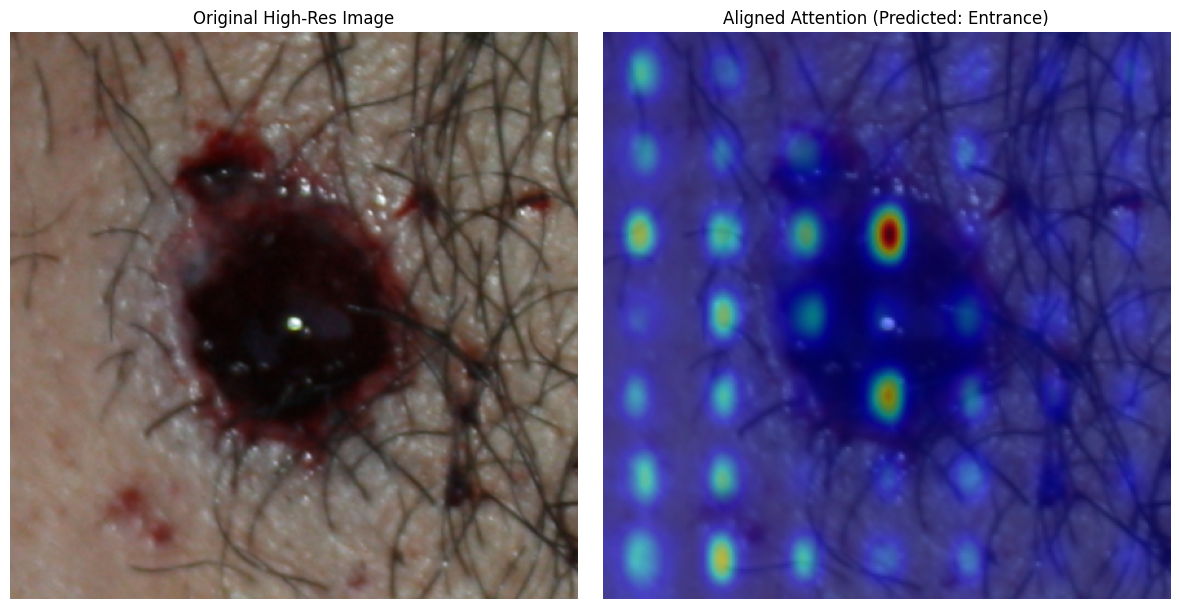

In [14]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

def visualize_clip_aligned(image_path, ft_model, preprocess, device):
    """
    Visualizes the attention of the fine-tuned CLIP model with perfect spatial alignment.
    This version uses the actual preprocessed image seen by the model as the background.
    """
    # 1. Load and Preprocess for the model
    image_raw = Image.open(image_path).convert('RGB')
    image_input = preprocess(image_raw).unsqueeze(0).to(device)
    image_input.requires_grad = True

    # 2. Forward pass
    outputs = ft_model(image_input)
    target_idx = torch.argmax(outputs)
    target_logit = outputs[0, target_idx]

    # 3. Backward pass to get gradients
    ft_model.zero_grad()
    target_logit.backward()

    # 4. Get gradients and process Saliency Map
    grad = image_input.grad.detach().cpu().numpy()[0]
    grad = np.max(np.abs(grad), axis=0)

    # Apply Gaussian Blur to smooth out ViT patch artifacts (the grid patterns)
    grad = cv2.GaussianBlur(grad, (15, 15), 0)

    # Normalize the saliency map
    grad = (grad - grad.min()) / (grad.max() - grad.min() + 1e-8)

    # 5. Prepare the 'Model's Eye View' as background
    # We must de-normalize the preprocessed tensor to show it as a clear image
    inv_img = image_input.squeeze().permute(1, 2, 0).detach().cpu().numpy()

    # CLIP preprocessing usually involves normalization.
    # For visualization, we bring it back to 0-1 range.
    inv_img = (inv_img - inv_img.min()) / (inv_img.max() - inv_img.min() + 1e-8)

    # 6. Final Plotting with perfect alignment
    plt.figure(figsize=(12, 6))

    # Left: The Original Image (for reference)
    plt.subplot(1, 2, 1)
    plt.imshow(image_raw)
    plt.title("Original High-Res Image")
    plt.axis('off')

    # Right: The Aligned Saliency Map (what the model actually processed)
    plt.subplot(1, 2, 2)
    plt.imshow(inv_img) # This is the 224x224 cropped input
    plt.imshow(grad, cmap='jet', alpha=0.5) # Heatmap perfectly matches pixels
    plt.title(f"Aligned Attention (Predicted: {'Entrance' if target_idx == 0 else 'Exit'})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization with the fixed spatial logic
visualize_clip_aligned(test_dataset.imgs[2][0], fine_tune_model, preprocess, device)